In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
import plotly.express as px
import zipfile
from io import BytesIO
import requests
import statsmodels.api as sm
import matplotlib.gridspec as gridspec
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

[*********************100%***********************]  11 of 11 completed


   1. TABLEAU DES PERFORMANCES PAR ACTIF
                      Actif Rendement Annualisé Volatilité Annualisée Ratio de Sharpe Max Drawdown
Ticker                                                                                            
BTC-USD              Crypto              69.89%                68.12%           0.997      -81.69%
GLD                    Gold              14.14%                14.46%           0.840      -19.83%
MTUM            US Momentum              15.06%                19.96%           0.654      -31.94%
VEA               Dev Ex-US               9.48%                16.86%           0.444      -34.62%
IEMG        Emerging Market               9.30%                17.96%           0.406      -37.08%
VIOV     US Small Cap Value              10.42%                23.93%           0.352      -46.33%
IJS            US Small Cap              10.26%                23.86%           0.346      -46.22%
VNQ            Immo (REITs)               5.45%                21.97

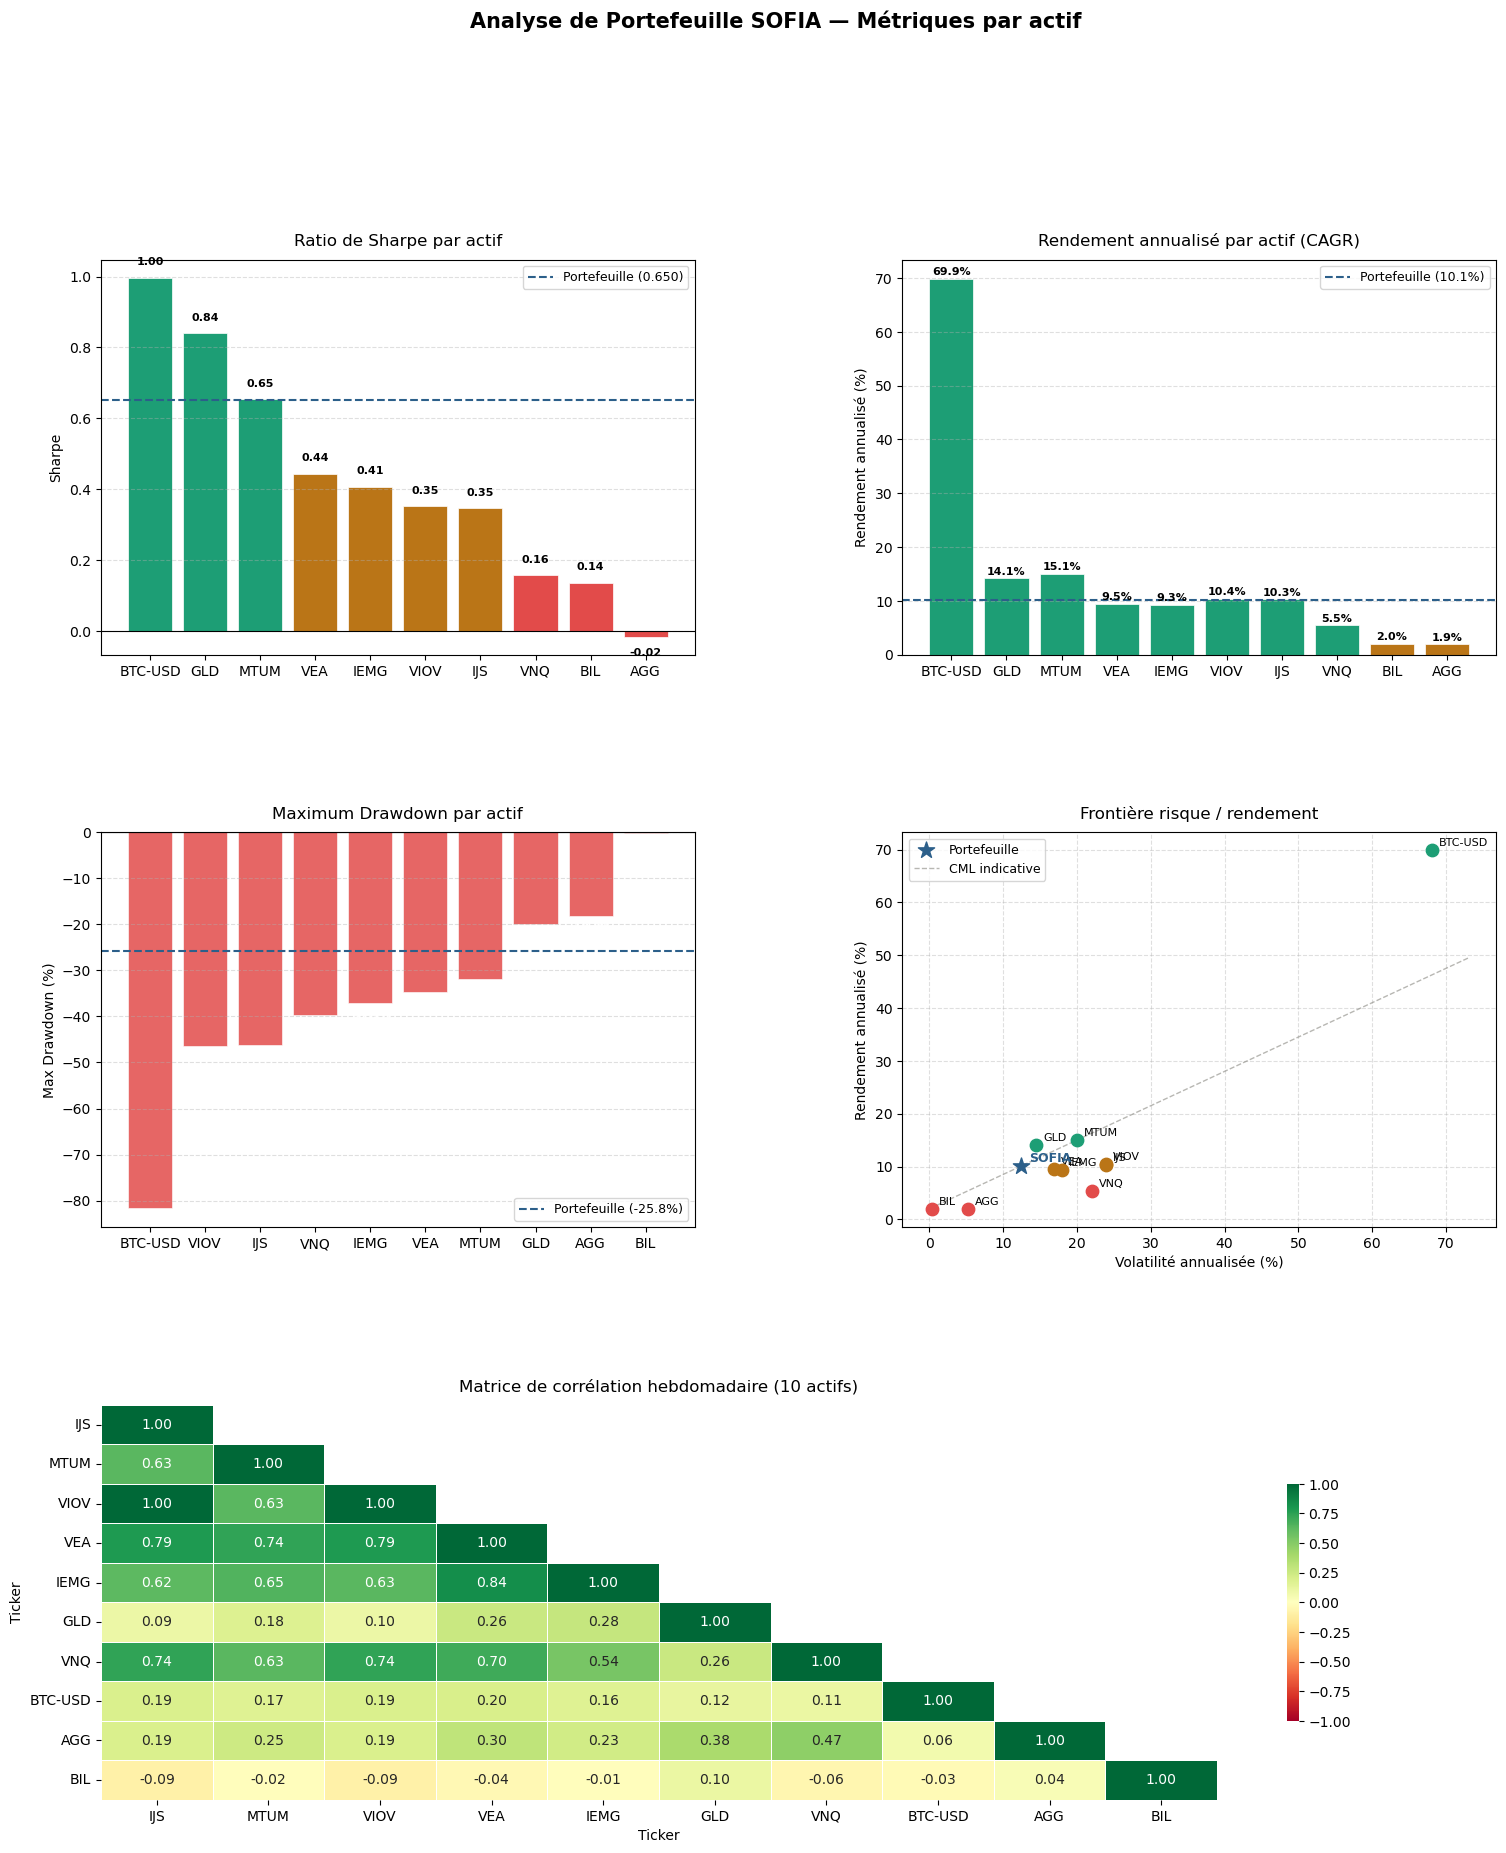

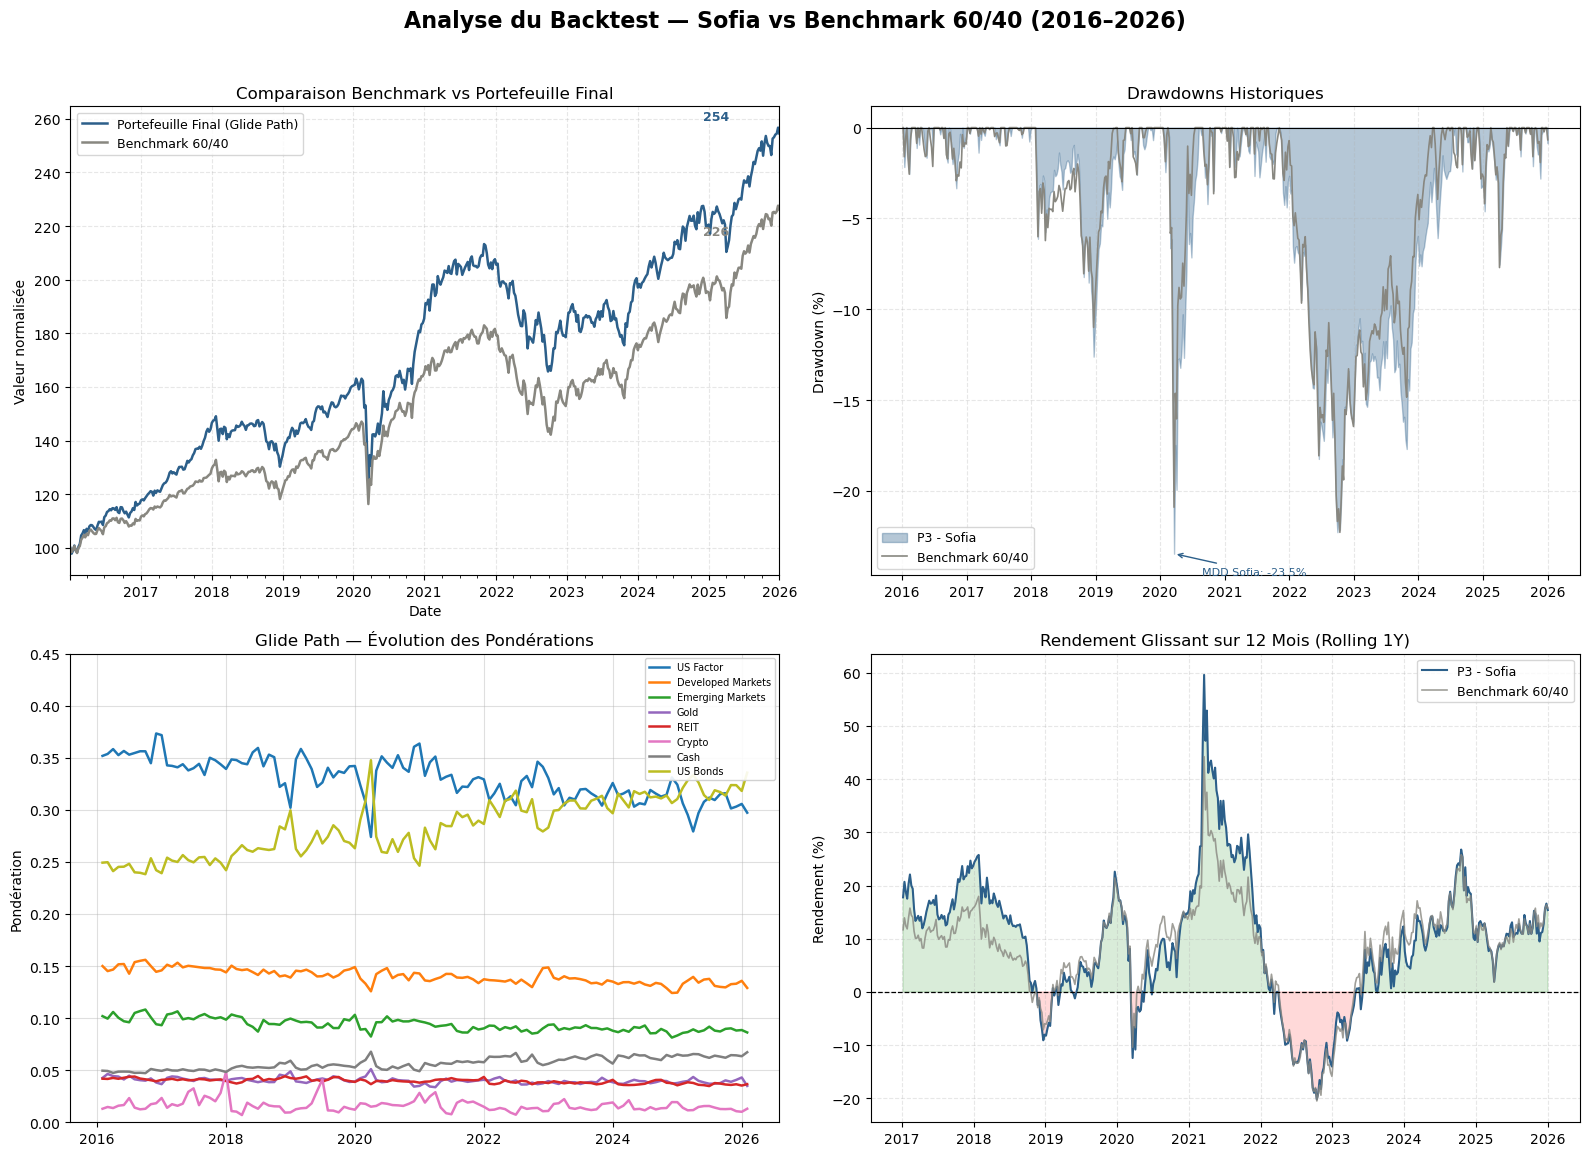


Terminé — 9 graphiques générés.


In [2]:
#Partie du code réalisée par Hugo 


"""
================================================================================
  ANALYSE DE PORTEFEUILLE SOFIA — Backtest 2016–2026
  Fusion des cellules 4 (métriques par actif) et 5 (backtest + Glide Path)
================================================================================
"""

START_DATE      = "2016-01-01"
END_DATE        = "2026-01-01"
RISK_FREE_RATE  = 0.02
WEEKS_PER_YEAR  = 52
CAPITAL_INITIAL = 350_000.0

TICKERS = ['IJS', 'MTUM', 'VIOV', 'VEA', 'IEMG', 'GLD', 'VNQ', 'BTC-USD', 'AGG', 'BIL']
LABELS  = {
    'IJS':     'US Small Cap',
    'MTUM':    'US Momentum',
    'VIOV':    'US Small Cap Value',
    'VEA':     'Dev Ex-US',
    'IEMG':    'Emerging Market',
    'GLD':     'Gold',
    'VNQ':     'Immo (REITs)',
    'BTC-USD': 'Crypto',
    'AGG':     'Obligations',
    'BIL':     'Cash',
}
WEIGHTS_ARRAY = np.array([0.14, 0.1225, 0.0875, 0.15, 0.10, 0.0425, 0.0425, 0.015, 0.25, 0.05])
BASE_WEIGHTS_P3 = dict(zip(TICKERS, WEIGHTS_ARRAY))

RISKY_ASSETS = ['IJS', 'MTUM', 'VIOV', 'VEA', 'IEMG', 'GLD', 'VNQ', 'BTC-USD']
SAFE_ASSETS  = ['AGG', 'BIL']
RISKY_TOTAL  = sum(BASE_WEIGHTS_P3[t] for t in RISKY_ASSETS)   # 0.70
SAFE_TOTAL   = sum(BASE_WEIGHTS_P3[t] for t in SAFE_ASSETS)    # 0.30

# Benchmark 60/40
BENCH_ASSETS       = ['VT', 'AGG']
BASE_WEIGHTS_BENCH = {'VT': 0.60, 'AGG': 0.40}

assert abs(WEIGHTS_ARRAY.sum() - 1.0) < 1e-6, "Somme des poids P3 ≠ 1"
C_BLUE  = '#2C5F8A'
C_GRAY  = '#888780'
C_GREEN = '#1D9E75'
C_RED   = '#E24B4A'
C_AMBER = '#BA7517'
all_tickers = list(set(TICKERS + BENCH_ASSETS))

raw = yf.download(all_tickers, start=START_DATE, end=END_DATE, auto_adjust=True)['Close']

weekly_prices = raw.resample('W-FRI').last().ffill(limit=5)

weekly_prices_p3  = weekly_prices[TICKERS]
weekly_returns_p3 = weekly_prices_p3.pct_change().iloc[1:]
weekly_prices_bm  = weekly_prices[BENCH_ASSETS]
weekly_returns_bm = weekly_prices_bm.pct_change().iloc[1:]



# 3. FONCTIONS MÉTRIQUES

def annualized_return(prices_series):
    """Rendement annualisé basé sur : (1 + R_cum)^(365 / N_days) - 1"""
    clean = prices_series.dropna()

    if len(clean) < 2:
        return np.nan

    cumulative_return = (clean.iloc[-1] / clean.iloc[0]) - 1

    if hasattr(clean.index, 'to_pydatetime'):
        n_days = (clean.index[-1] - clean.index[0]).days
    else:
        n_days = int(((len(clean) - 1) / WEEKS_PER_YEAR) * 365)

    if n_days <= 0:
        return np.nan

    return (1 + cumulative_return) ** (365 / n_days) - 1

def annualized_volatility(returns_series):
    """Vol annualisée = vol hebdo × √52"""
    return returns_series.dropna().std() * np.sqrt(WEEKS_PER_YEAR)

def sharpe_ratio(ann_ret, ann_vol, rf=RISK_FREE_RATE):
    return np.nan if ann_vol == 0 else (ann_ret - rf) / ann_vol

def sortino_ratio(returns_series, ann_ret, rf=RISK_FREE_RATE):
    """Ratio de Sortino basé sur la volatilité baissière."""
    clean = returns_series.dropna()

    if len(clean) == 0:
        return np.nan

    downside_returns = clean[clean < 0]

    if len(downside_returns) == 0:
        return np.nan

    downside_vol = downside_returns.std() * np.sqrt(WEEKS_PER_YEAR)

    return np.nan if downside_vol == 0 else (ann_ret - rf) / downside_vol

def max_drawdown(returns_series):
    clean = returns_series.dropna()
    cum = (1 + clean).cumprod()
    return (cum / cum.cummax() - 1).min()

def calmar_ratio(ann_ret, max_dd):
    """Ratio de Calmar = rendement annualisé / drawdown maximal."""
    return np.nan if max_dd == 0 else ann_ret / abs(max_dd)


# 4. MÉTRIQUES PAR ACTIF

results = []
for ticker in TICKERS:
    prices = weekly_prices_p3[ticker]
    rets   = weekly_returns_p3[ticker]
    ann_r  = annualized_return(prices)
    ann_v  = annualized_volatility(rets)
    results.append({
        'Ticker':                ticker,
        'Actif':                 LABELS[ticker],
        'Rendement Annualisé':   ann_r,
        'Volatilité Annualisée': ann_v,
        'Ratio de Sharpe':       sharpe_ratio(ann_r, ann_v),
        'Ratio de Sortino':     sortino_ratio(rets, ann_r),
        'Max Drawdown':          max_drawdown(rets),
        'Ratio de Calmar':      calmar_ratio(ann_r, max_drawdown(rets)),
    })

df_assets = pd.DataFrame(results).set_index('Ticker')
df_sorted = df_assets.sort_values('Ratio de Sharpe', ascending=False)

# Métriques portefeuille global (sur semaines complètes)
aligned = weekly_returns_p3.dropna()
port_weekly = aligned.dot(WEIGHTS_ARRAY)
port_prices = (1 + port_weekly).cumprod() * 100

port_ann_ret = annualized_return(port_prices)
port_ann_vol = annualized_volatility(port_weekly)
port_sharpe   = sharpe_ratio(port_ann_ret, port_ann_vol)
port_sortino = sortino_ratio(port_weekly, port_ann_ret)
port_mdd      = max_drawdown(port_weekly)
port_calmar  = calmar_ratio(port_ann_ret, port_mdd)

print("=" * 65)
print("   1. TABLEAU DES PERFORMANCES PAR ACTIF")
print("=" * 65)
print(df_sorted[['Actif', 'Rendement Annualisé', 'Volatilité Annualisée',
                  'Ratio de Sharpe', 'Max Drawdown']].to_string(
    formatters={
        'Rendement Annualisé':   '{:.2%}'.format,
        'Volatilité Annualisée': '{:.2%}'.format,
        'Ratio de Sharpe':       '{:.3f}'.format,
        'Max Drawdown':          '{:.2%}'.format,
    }
))

print("\n" + "=" * 65)
print("   RÉSUMÉ DU PORTEFEUILLE GLOBAL")
print("=" * 65)
print(f"  Période analysée      : {aligned.index[0].date()} → {aligned.index[-1].date()}")
print(f"  Rendement Annualisé   : {port_ann_ret:.2%}")
print(f"  Volatilité Annualisée : {port_ann_vol:.2%}")
print(f"  Maximum Drawdown      : {port_mdd:.2%}")
print(f"  Ratio de Sharpe       : {port_sharpe:.3f}")


# 5. MOTEUR DE BACKTEST AVEC GLIDE PATH
capital_p3    = CAPITAL_INITIAL
capital_bench = CAPITAL_INITIAL

current_w_p3    = pd.Series(BASE_WEIGHTS_P3)
current_w_bench = pd.Series(BASE_WEIGHTS_BENCH)

history_p3, history_bench, weights_history = [], [], []
last_quarter = -1
start_year   = int(weekly_returns_p3.index[0].year)

common_index = weekly_returns_p3.index.intersection(weekly_returns_bm.index)

print("\nSimulation du backtest et du Glide Path...")
for date in common_index:
    ret_p3 = weekly_returns_p3.loc[date]
    ret_bm = weekly_returns_bm.loc[date]
    year, quarter = int(date.year), int(date.quarter)

    # Rééquilibrage trimestriel + Glide Path
    if quarter != last_quarter:
        current_w_bench = pd.Series(BASE_WEIGHTS_BENCH)
        years_passed  = year - start_year
        risky_target  = max(0.60, RISKY_TOTAL - years_passed * 0.01)
        safe_target   = 1.0 - risky_target

        target_w = current_w_p3.copy()
        for tk in RISKY_ASSETS:
            target_w[tk] = (BASE_WEIGHTS_P3[tk] / RISKY_TOTAL) * risky_target
        for tk in SAFE_ASSETS:
            target_w[tk] = (BASE_WEIGHTS_P3[tk] / SAFE_TOTAL) * safe_target
        current_w_p3 = target_w
        last_quarter = quarter

    # Rendement hebdomadaire
    rp = ret_p3.fillna(0)
    rb = ret_bm.fillna(0)
    port_ret_p3   = np.dot(current_w_p3,    rp[current_w_p3.index])
    port_ret_bench = np.dot(current_w_bench, rb[current_w_bench.index])

    # Croissance du capital
    capital_p3    *= (1 + port_ret_p3)
    capital_bench *= (1 + port_ret_bench)

    # Dérive des poids
    current_w_p3   = current_w_p3 * (1 + rp[current_w_p3.index])
    current_w_p3  /= current_w_p3.sum()
    current_w_bench  = current_w_bench * (1 + rb[current_w_bench.index])
    current_w_bench /= current_w_bench.sum()

    history_p3.append(capital_p3)
    history_bench.append(capital_bench)
    weights_history.append(current_w_p3.copy())

df_capital = pd.DataFrame(
    {'P3 - Sofia': history_p3, 'Benchmark 60/40': history_bench},
    index=common_index
)
df_weights = pd.DataFrame(weights_history, index=common_index)


# 6. MÉTRIQUES DU BACKTEST
rets_series = df_capital.pct_change().dropna()

ret_p3  = annualized_return(df_capital['P3 - Sofia'])
vol_p3  = annualized_volatility(rets_series['P3 - Sofia'])
sh_p3   = sharpe_ratio(ret_p3, vol_p3)
mdd_p3  = max_drawdown(rets_series['P3 - Sofia'])
sort_p3 = sortino_ratio(rets_series['P3 - Sofia'], ret_p3)
cal_p3  = calmar_ratio(ret_p3, mdd_p3)

ret_bm  = annualized_return(df_capital['Benchmark 60/40'])
vol_bm  = annualized_volatility(rets_series['Benchmark 60/40'])
sh_bm   = sharpe_ratio(ret_bm, vol_bm)
mdd_bm  = max_drawdown(rets_series['Benchmark 60/40'])
sort_bm = sortino_ratio(rets_series['Benchmark 60/40'], ret_bm)
cal_bm  = calmar_ratio(ret_bm, mdd_bm)

cov_val        = rets_series.cov().iloc[0, 1]
beta           = cov_val / rets_series['Benchmark 60/40'].var()
jensen_alpha   = ret_p3 - (RISK_FREE_RATE + beta * (ret_bm - RISK_FREE_RATE))
tracking_error = (rets_series['P3 - Sofia'] - rets_series['Benchmark 60/40']).std() * np.sqrt(WEEKS_PER_YEAR)
info_ratio     = (ret_p3 - ret_bm) / tracking_error

print("\n" + "=" * 55)
print("   2. RÉSULTATS DU BACKTEST : SOFIA vs BENCHMARK 60/40")
print("=" * 55)
print(f"  Capital Final P3 (Sofia)  : {df_capital['P3 - Sofia'].iloc[-1]:>12,.0f} USD")
print(f"  Capital Final Benchmark   : {df_capital['Benchmark 60/40'].iloc[-1]:>12,.0f} USD")
print(f"  {'Métrique':<26} {'P3 - Sofia':>10} {'Benchmark':>10}")
print(f"  {'-'*46}")
print(f"  {'Rendement Annualisé':<26} {ret_p3:>10.2%} {ret_bm:>10.2%}")
print(f"  {'Volatilité Annualisée':<26} {vol_p3:>10.2%} {vol_bm:>10.2%}")
print(f"  {'Ratio de Sharpe':<26} {sh_p3:>10.3f} {sh_bm:>10.3f}")
print(f"  {'Ratio de Sortino':<26} {sort_p3:>10.3f} {sort_bm:>10.3f}")
print(f"  {'Ratio de Calmar':<26} {cal_p3:>10.3f} {cal_bm:>10.3f}")
print(f"  {'Max Drawdown':<26} {mdd_p3:>10.2%} {mdd_bm:>10.2%}")
print(f"  {'-'*46}")
print(f"  {'Tracking Error':<26} {tracking_error:>10.2%}")
print(f"  {'Alpha de Jensen':<26} {jensen_alpha:>10.2%}")
print(f"  {'Ratio d\'Information':<26} {info_ratio:>10.3f}")



# 7. GRAPHIQUES — PARTIE 1 : Analyse par actif (5 graphiques)


fig1 = plt.figure(figsize=(18, 20))
gs1  = gridspec.GridSpec(3, 2, figure=fig1, hspace=0.45, wspace=0.35)

def bar_color(val, high=0.5, mid=0.2):
    return C_GREEN if val >= high else C_AMBER if val >= mid else C_RED

ax1 = fig1.add_subplot(gs1[0, 0])
sharpe_vals   = df_sorted['Ratio de Sharpe']
colors_sharpe = [bar_color(v) for v in sharpe_vals]
bars = ax1.bar(sharpe_vals.index, sharpe_vals, color=colors_sharpe, edgecolor='white', linewidth=0.5)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axhline(port_sharpe, color=C_BLUE, linewidth=1.5, linestyle='--',
            label=f'Portefeuille ({port_sharpe:.3f})')
for b, v in zip(bars, sharpe_vals):
    ax1.text(b.get_x() + b.get_width() / 2, v + (0.03 if v >= 0 else -0.06),
             f'{v:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.set_title('Ratio de Sharpe par actif', fontsize=12, pad=10)
ax1.set_ylabel('Sharpe')
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = fig1.add_subplot(gs1[0, 1])
ret_vals   = df_sorted['Rendement Annualisé'] * 100
colors_ret = [bar_color(v, high=5, mid=0) for v in ret_vals]
bars = ax2.bar(ret_vals.index, ret_vals, color=colors_ret, edgecolor='white', linewidth=0.5)
ax2.axhline(port_ann_ret * 100, color=C_BLUE, linewidth=1.5, linestyle='--',
            label=f'Portefeuille ({port_ann_ret:.1%})')
for b, v in zip(bars, ret_vals):
    ax2.text(b.get_x() + b.get_width() / 2, v + 0.3,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.set_title('Rendement annualisé par actif (CAGR)', fontsize=12, pad=10)
ax2.set_ylabel('Rendement annualisé (%)')
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

ax3 = fig1.add_subplot(gs1[1, 0])
dd_vals = df_assets.sort_values('Max Drawdown', ascending=True)['Max Drawdown'] * 100
bars = ax3.bar(dd_vals.index, dd_vals, color=C_RED, edgecolor='white', linewidth=0.5, alpha=0.85)
ax3.axhline(port_mdd * 100, color=C_BLUE, linewidth=1.5, linestyle='--',
            label=f'Portefeuille ({port_mdd:.1%})')
for b, v in zip(bars, dd_vals):
    ax3.text(b.get_x() + b.get_width() / 2, v - 1.5,
             f'{v:.1f}%', ha='center', va='top', fontsize=8, fontweight='bold', color='white')
ax3.set_title('Maximum Drawdown par actif', fontsize=12, pad=10)
ax3.set_ylabel('Max Drawdown (%)')
ax3.axhline(0, color='black', linewidth=0.8)
ax3.legend(fontsize=9)
ax3.grid(axis='y', linestyle='--', alpha=0.4)

ax4 = fig1.add_subplot(gs1[1, 1])
for ticker in TICKERS:
    x = df_assets.loc[ticker, 'Volatilité Annualisée'] * 100
    y = df_assets.loc[ticker, 'Rendement Annualisé'] * 100
    sh = df_assets.loc[ticker, 'Ratio de Sharpe']
    ax4.scatter(x, y, s=80, zorder=5, color=bar_color(sh))
    ax4.annotate(ticker, (x, y), textcoords='offset points', xytext=(5, 3), fontsize=8)
ax4.scatter(port_ann_vol * 100, port_ann_ret * 100, s=150,
            marker='*', color=C_BLUE, zorder=6, label='Portefeuille')
ax4.annotate('SOFIA', (port_ann_vol * 100, port_ann_ret * 100),
             textcoords='offset points', xytext=(6, 3), fontsize=9,
             fontweight='bold', color=C_BLUE)
vol_range = np.linspace(0, df_assets['Volatilité Annualisée'].max() * 100 + 5, 100)
ax4.plot(vol_range, RISK_FREE_RATE * 100 + port_sharpe * vol_range,
         color=C_GRAY, linestyle='--', linewidth=1, alpha=0.6, label='CML indicative')
ax4.set_title('Frontière risque / rendement', fontsize=12, pad=10)
ax4.set_xlabel('Volatilité annualisée (%)')
ax4.set_ylabel('Rendement annualisé (%)')
ax4.legend(fontsize=9)
ax4.grid(linestyle='--', alpha=0.4)

ax5 = fig1.add_subplot(gs1[2, :])
corr = weekly_returns_p3[TICKERS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, cmap='RdYlGn',
            vmin=-1, vmax=1, fmt='.2f', linewidths=0.5,
            ax=ax5, cbar_kws={'shrink': 0.6},
            xticklabels=TICKERS, yticklabels=TICKERS)
ax5.set_title('Matrice de corrélation hebdomadaire (10 actifs)', fontsize=12, pad=10)

fig1.suptitle('Analyse de Portefeuille SOFIA — Métriques par actif',
              fontsize=15, fontweight='bold', y=1.005)
plt.show()

# 8. GRAPHIQUES — PARTIE 2 : Backtest & Glide Path (4 graphiques)

fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle('Analyse du Backtest — Sofia vs Benchmark 60/40 (2016–2026)',fontsize=16, fontweight='bold')
df_normalized = df_capital / df_capital.iloc[0] * 100
df_normalized.plot(
    ax=axes[0, 0],
    title='Comparaison Benchmark vs Portefeuille Final',
    color=[C_BLUE, C_GRAY],
    linewidth=1.8)
axes[0, 0].set_ylabel('Valeur normalisée')
axes[0, 0].grid(True, linestyle='--', alpha=0.3)
axes[0, 0].legend(
    ['Portefeuille Final (Glide Path)', 'Benchmark 60/40'],
    fontsize=9)

axes[0, 0].annotate(
    f"{df_normalized['P3 - Sofia'].iloc[-1]:.0f}",
    xy=(df_normalized.index[-1], df_normalized['P3 - Sofia'].iloc[-1]),
    xytext=(-55, 10),
    textcoords='offset points',
    fontsize=9,
    color=C_BLUE,
    fontweight='bold')
axes[0, 0].annotate(
    f"{df_normalized['Benchmark 60/40'].iloc[-1]:.0f}",
    xy=(df_normalized.index[-1], df_normalized['Benchmark 60/40'].iloc[-1]),
    xytext=(-55, -18),
    textcoords='offset points',
    fontsize=9,
    color=C_GRAY,
    fontweight='bold')

axes[0, 0].set_xlabel('Date')
dd_p3 = df_capital['P3 - Sofia']      / df_capital['P3 - Sofia'].cummax()      - 1
dd_bm = df_capital['Benchmark 60/40'] / df_capital['Benchmark 60/40'].cummax() - 1

axes[0, 1].fill_between(dd_p3.index, dd_p3 * 100, 0,
                         color=C_BLUE, alpha=0.35, label='P3 - Sofia')
axes[0, 1].plot(dd_bm.index, dd_bm * 100, color=C_GRAY, linewidth=1.2, label='Benchmark 60/40')
axes[0, 1].axhline(0, color='black', linewidth=0.8)
axes[0, 1].set_title('Drawdowns Historiques')
axes[0, 1].set_ylabel('Drawdown (%)')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, linestyle='--', alpha=0.3)
axes[0, 1].annotate(f"MDD Sofia: {mdd_p3:.1%}",
    xy=(dd_p3.idxmin(), mdd_p3 * 100), xytext=(20, -15), textcoords='offset points',
    fontsize=8, color=C_BLUE, arrowprops=dict(arrowstyle='->', color=C_BLUE))

df_gp = pd.DataFrame(index=df_weights.index)
df_gp['US Factor']         = df_weights['IJS'] + df_weights['MTUM'] + df_weights['VIOV']
df_gp['Developed Markets'] = df_weights['VEA']
df_gp['Emerging Markets']  = df_weights['IEMG']
df_gp['Gold']              = df_weights['GLD']
df_gp['REIT']              = df_weights['VNQ']
df_gp['Crypto']            = df_weights['BTC-USD']
df_gp['Cash']              = df_weights['BIL']
df_gp['US Bonds']          = df_weights['AGG']

GP_COLORS = {
    'US Factor':         '#1f77b4',
    'Developed Markets': '#ff7f0e',
    'Emerging Markets':  '#2ca02c',
    'Gold':              '#9467bd',
    'REIT':              '#d62728',
    'Crypto':            '#e377c2',
    'Cash':              '#7f7f7f',
    'US Bonds':          '#bcbd22',
}

df_gp_monthly = df_gp.resample('ME').last()
for col, color in GP_COLORS.items():
    axes[1, 0].plot(df_gp_monthly.index, df_gp_monthly[col],
                    label=col, color=color, linewidth=1.8)
axes[1, 0].set_title('Glide Path — Évolution des Pondérations')
axes[1, 0].set_ylabel('Pondération')
axes[1, 0].set_ylim(0, 0.45)
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
axes[1, 0].legend(fontsize=7, loc='upper right', framealpha=0.9)
axes[1, 0].grid(True, linestyle='-', alpha=0.4)

# ── G4 : Rendement Glissant 12 Mois ─────────────────────────────────────────
rolling_p3 = df_capital['P3 - Sofia'].pct_change(periods=52).dropna() * 100
rolling_bm = df_capital['Benchmark 60/40'].pct_change(periods=52).dropna() * 100

axes[1, 1].plot(rolling_p3.index, rolling_p3, label='P3 - Sofia', color=C_BLUE, linewidth=1.5)
axes[1, 1].plot(rolling_bm.index, rolling_bm, label='Benchmark 60/40', color=C_GRAY,
                linewidth=1.2, alpha=0.8)
axes[1, 1].fill_between(rolling_p3.index, rolling_p3, 0,
                         where=(rolling_p3 > 0), alpha=0.15, color='green')
axes[1, 1].fill_between(rolling_p3.index, rolling_p3, 0,
                         where=(rolling_p3 < 0), alpha=0.15, color='red')
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.9)
axes[1, 1].set_title('Rendement Glissant sur 12 Mois (Rolling 1Y)')
axes[1, 1].set_ylabel('Rendement (%)')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

print("\nTerminé — 9 graphiques générés.")

In [3]:
# ALIAS DE COMPATIBILITÉ POUR LES CELLULES SUIVANTES

# 

# Prix quotidiens ajustés
data = raw.copy()

# Rendements hebdomadaires de tous les actifs utiles
weekly_returns = weekly_prices.pct_change().dropna()

# Taux sans risque
risk_free_rate = RISK_FREE_RATE

# Sécurité : on vérifie que les actifs nécessaires sont bien présents
required_cols = ["VT", "AGG", "IJS", "MTUM", "VIOV"]

missing_cols = [c for c in required_cols if c not in data.columns]

if missing_cols:
    raise ValueError(f"Colonnes manquantes dans data : {missing_cols}")

print("Alias créés correctement : data, weekly_returns, risk_free_rate")

Alias créés correctement : data, weekly_returns, risk_free_rate


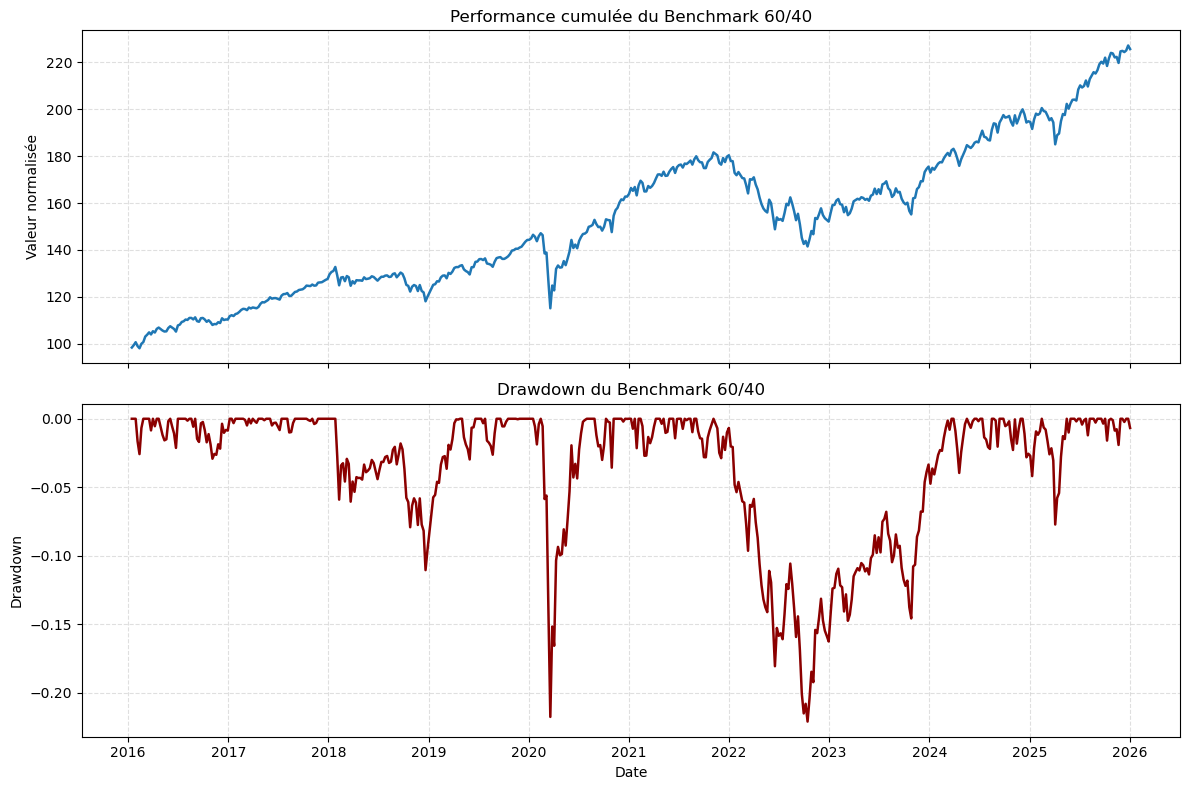

Max Drawdown Benchmark : -22.09 %


In [4]:
# Partie du Code réalisé par Baptiste

# --- BENCHMARK 60/40 : PERFORMANCE CUMULÉE + DRAWDOWN ---

benchmark_weights = {
    "VT": 0.60,
    "AGG": 0.40
}

benchmark_returns = weekly_returns[["VT", "AGG"]].dot(pd.Series(benchmark_weights))

benchmark_cumulative = (1 + benchmark_returns).cumprod() * 100

benchmark_running_max = benchmark_cumulative.cummax()
benchmark_drawdown = benchmark_cumulative / benchmark_running_max - 1

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(benchmark_cumulative, linewidth=1.8)
axes[0].set_title("Performance cumulée du Benchmark 60/40")
axes[0].set_ylabel("Valeur normalisée")
axes[0].grid(True, linestyle="--", alpha=0.4)

axes[1].plot(benchmark_drawdown, color="darkred", linewidth=1.8)
axes[1].set_title("Drawdown du Benchmark 60/40")
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print("Max Drawdown Benchmark :", round(benchmark_drawdown.min() * 100, 2), "%")

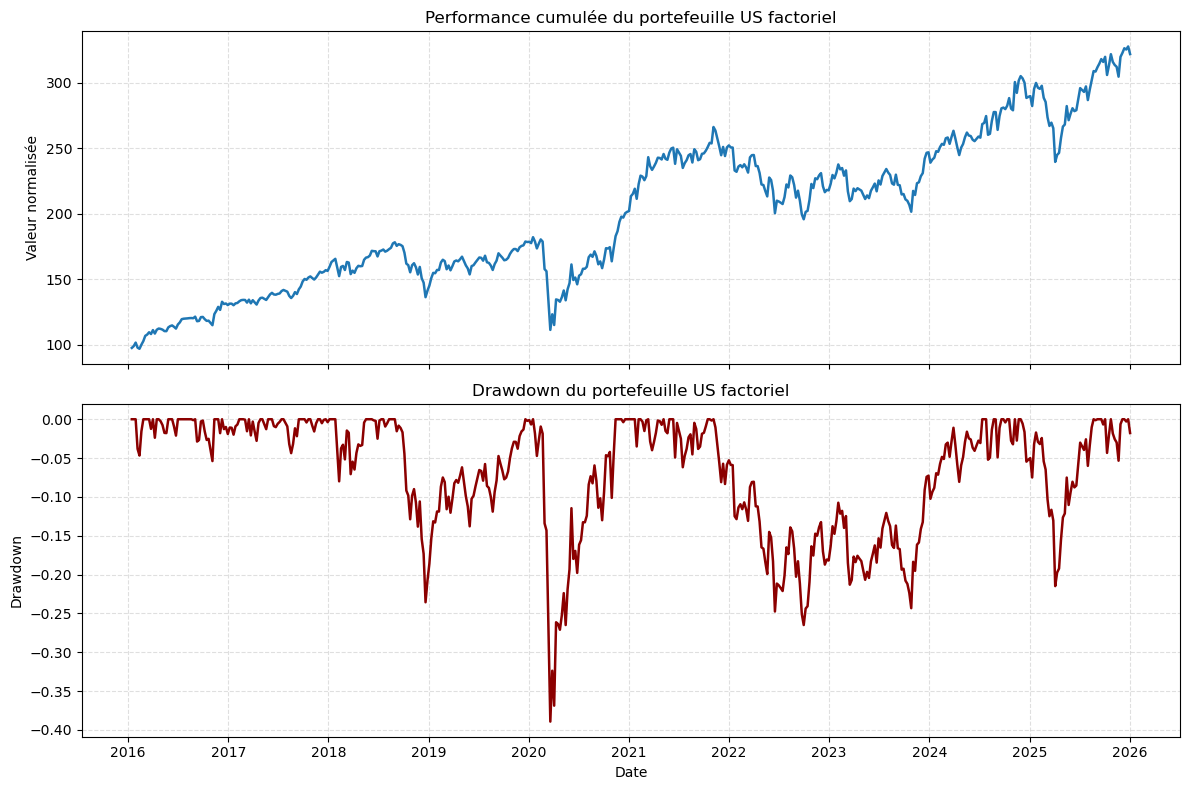

Max Drawdown PF2 : -38.93 %


In [5]:
# PORTFOLIO 2 : US EQUITY FACTOR PORTFOLIO 

pf2_weights = {
    "IJS": 0.40,
    "MTUM": 0.35,
    "VIOV": 0.25
}

pf2_weekly_returns = weekly_returns[["IJS", "MTUM", "VIOV"]].dot(pd.Series(pf2_weights))

pf2_cumulative = (1 + pf2_weekly_returns).cumprod() * 100

pf2_running_max = pf2_cumulative.cummax()
pf2_drawdown = pf2_cumulative / pf2_running_max - 1

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(pf2_cumulative, linewidth=1.8)
axes[0].set_title("Performance cumulée du portefeuille US factoriel")
axes[0].set_ylabel("Valeur normalisée")
axes[0].grid(True, linestyle="--", alpha=0.4)

axes[1].plot(pf2_drawdown, color="darkred", linewidth=1.8)
axes[1].set_title("Drawdown du portefeuille US factoriel")
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print("Max Drawdown PF2 :", round(pf2_drawdown.min() * 100, 2), "%")

In [6]:
# COMPARAISON DES MÉTRIQUES : BENCHMARK vs PF2 

def calculate_max_drawdown(returns_series):
    cumulative = (1 + returns_series).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = cumulative / rolling_max - 1
    return drawdown.min()

benchmark_ann_return = (1 + benchmark_returns.mean()) ** 52 - 1
benchmark_vol = benchmark_returns.std() * np.sqrt(52)
benchmark_sharpe = (benchmark_ann_return - risk_free_rate) / benchmark_vol
benchmark_max_dd = calculate_max_drawdown(benchmark_returns)

pf2_ann_return = (1 + pf2_weekly_returns.mean()) ** 52 - 1
pf2_vol = pf2_weekly_returns.std() * np.sqrt(52)
pf2_sharpe = (pf2_ann_return - risk_free_rate) / pf2_vol
pf2_max_dd = calculate_max_drawdown(pf2_weekly_returns)

active_returns = pf2_weekly_returns - benchmark_returns
tracking_error = active_returns.std() * np.sqrt(52)
information_ratio = (pf2_ann_return - benchmark_ann_return) / tracking_error

comparison_table = pd.DataFrame({
    "Benchmark 60/40": [
        benchmark_ann_return,
        benchmark_vol,
        benchmark_sharpe,
        abs(benchmark_max_dd),
        np.nan
    ],
    "US Factor Portfolio": [
        pf2_ann_return,
        pf2_vol,
        pf2_sharpe,
        abs(pf2_max_dd),
        information_ratio
    ]
}, index=[
    "Annualized Return",
    "Volatility",
    "Sharpe Ratio",
    "Max Drawdown",
    "Information Ratio"
])

comparison_table = comparison_table.round(4)

display(comparison_table)

,Benchmark 60/40,US Factor Portfolio
Annualized Return,0.0908,0.1481
Volatility,0.1061,0.2065
Sharpe Ratio,0.6670,0.6204
Max Drawdown,0.2209,0.3893
Information Ratio,NaN,0.4745


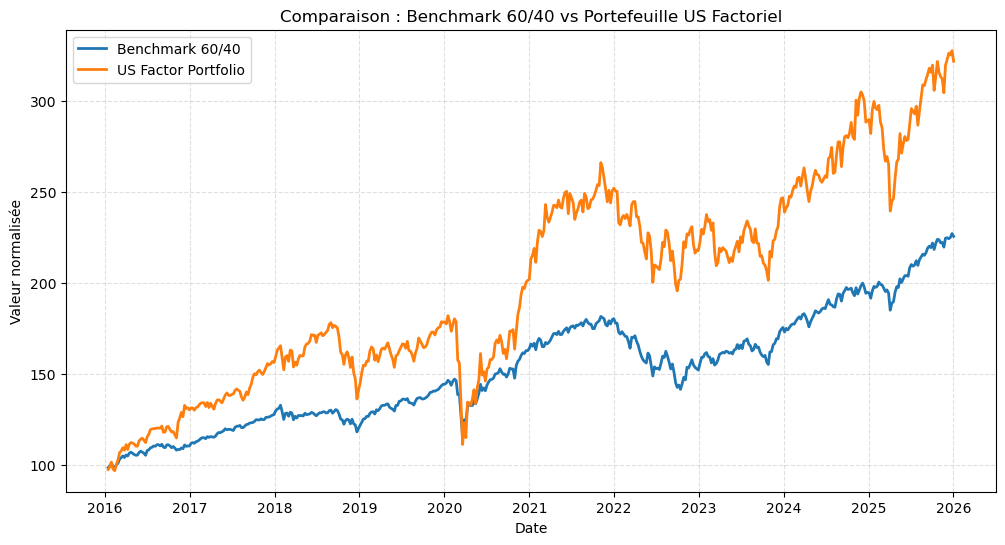

In [7]:
# COMPARAISON PERFORMANCE CUMULÉE : BENCHMARK vs PF2 

plt.figure(figsize=(12, 6))

plt.plot(
    benchmark_cumulative,
    label="Benchmark 60/40",
    linewidth=2
)

plt.plot(
    pf2_cumulative,
    label="US Factor Portfolio",
    linewidth=2
)

plt.title("Comparaison : Benchmark 60/40 vs Portefeuille US Factoriel")
plt.ylabel("Valeur normalisée")
plt.xlabel("Date")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

In [8]:
# FAMA-FRENCH 6 FACTORS REGRESSION — PORTFOLIO 2


# 1. Poids du portefeuille 2

pf2_weights = {
    "IJS": 0.40,
    "MTUM": 0.35,
    "VIOV": 0.25
}

# Vérification des tickers
missing = [t for t in pf2_weights if t not in data.columns]
if missing:
    raise ValueError(f"Tickers absents de data : {missing}")

# 2. Rendements mensuels du PF2

pf2_prices = raw[list(pf2_weights.keys())].resample("M").last()
pf2_asset_returns = pf2_prices.pct_change().dropna()

pf2_returns = pf2_asset_returns.dot(pd.Series(pf2_weights))
pf2_returns.name = "PF2"

# IMPORTANT : on passe en PeriodIndex mensuel pour matcher Fama-French
pf2_returns.index = pf2_returns.index.to_period("M")

# 3. Fonction de téléchargement Kenneth French

def load_french_zip(url, skiprows):
    r = requests.get(url)
    z = zipfile.ZipFile(BytesIO(r.content))
    file_name = z.namelist()[0]

    raw = pd.read_csv(z.open(file_name), skiprows=skiprows)
    raw = raw.rename(columns={raw.columns[0]: "Date"})
    raw = raw[raw["Date"].astype(str).str.match(r"^\d{6}$")]

    raw["Date"] = pd.PeriodIndex(raw["Date"].astype(str), freq="M")
    raw = raw.set_index("Date")

    raw.columns = raw.columns.str.strip()
    return raw.astype(float) / 100

# 4. Facteurs FF5 + Momentum

ff5_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip"
mom_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_CSV.zip"

ff5 = load_french_zip(ff5_url, skiprows=3)
mom = load_french_zip(mom_url, skiprows=13)

ff5 = ff5.rename(columns={"Mkt-RF": "MKT_RF"})
mom = mom.rename(columns={"Mom": "MOM"})

ff6 = ff5[["MKT_RF", "SMB", "HML", "RMW", "CMA", "RF"]].join(
    mom[["MOM"]],
    how="inner"
)
# 5. Fusion PF2 + facteurs

regression_data_pf2 = pd.concat([pf2_returns, ff6], axis=1).dropna()

print("Nombre d'observations utilisées :", len(regression_data_pf2))
print("Première date :", regression_data_pf2.index.min())
print("Dernière date :", regression_data_pf2.index.max())

if len(regression_data_pf2) == 0:
    raise ValueError("La base de régression est vide : problème d'alignement des dates.")

# 6. Régression FF6

regression_data_pf2["PF2_excess"] = regression_data_pf2["PF2"] - regression_data_pf2["RF"]

Y = regression_data_pf2["PF2_excess"]

X = regression_data_pf2[["MKT_RF", "SMB", "HML", "RMW", "CMA", "MOM"]]
X = sm.add_constant(X)

ff6_model_pf2 = sm.OLS(Y, X).fit()

print(ff6_model_pf2.summary())

# 7. Tableau propre pour le rapport

ff6_results_pf2 = pd.DataFrame({
    "Beta": ff6_model_pf2.params,
    "t-stat": ff6_model_pf2.tvalues,
    "p-value": ff6_model_pf2.pvalues
}).round(4)

display(ff6_results_pf2)

ff6_summary_pf2 = pd.DataFrame({
    "Metric": [
        "R-squared",
        "Adjusted R-squared",
        "Monthly Alpha",
        "Annualized Alpha"
    ],
    "Value": [
        ff6_model_pf2.rsquared,
        ff6_model_pf2.rsquared_adj,
        ff6_model_pf2.params["const"],
        (1 + ff6_model_pf2.params["const"])**12 - 1
    ]
}).round(4)

display(ff6_summary_pf2)

Nombre d'observations utilisées : 119
Première date : 2016-02
Dernière date : 2025-12
                            OLS Regression Results                            
Dep. Variable:             PF2_excess   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     1070.
Date:                Sun, 24 May 2026   Prob (F-statistic):           2.03e-96
Time:                        12:33:59   Log-Likelihood:                 421.51
No. Observations:                 119   AIC:                            -829.0
Df Residuals:                     112   BIC:                            -809.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

,Beta,t-stat,p-value
const,-0.0012,-1.6928,0.0933
MKT_RF,1.0127,60.3251,0.0000
SMB,0.5781,19.3538,0.0000
HML,0.2161,8.5279,0.0000
RMW,0.0427,1.2461,0.2153
CMA,0.0491,1.3098,0.1929
MOM,0.1206,5.6259,0.0000


,Metric,Value
0,R-squared,0.9829
1,Adjusted R-squared,0.9819
2,Monthly Alpha,-0.0012
3,Annualized Alpha,-0.0140


In [9]:
# --- TABLEAU FAMA-FRENCH ---
ff6_report_table = pd.DataFrame({
    "Beta": ff6_model_pf2.params,
    "t-statistic": ff6_model_pf2.tvalues,
    "p-value": ff6_model_pf2.pvalues
})

ff6_report_table["Adjusted R²"] = ff6_model_pf2.rsquared_adj

ff6_report_table = ff6_report_table.round(4)

display(ff6_report_table)

,Beta,t-statistic,p-value,Adjusted R²
const,-0.0012,-1.6928,0.0933,0.9819
MKT_RF,1.0127,60.3251,0.0000,0.9819
SMB,0.5781,19.3538,0.0000,0.9819
HML,0.2161,8.5279,0.0000,0.9819
RMW,0.0427,1.2461,0.2153,0.9819
CMA,0.0491,1.3098,0.1929,0.9819
MOM,0.1206,5.6259,0.0000,0.9819
